# 第53课 · 🎨 看见 MFCC 的诞生——波形 → 声谱图（spectrogram） → Mel 谱 → 倒谱系数逐层图解

**目标**：把 MFCC 的诞生过程真正画出来：波形 → 声谱图 → Mel → 倒谱系数逐层图解。

> **🎨 收官**：轻文字，对照 L50 管线；读图即可。

🔗 Aurora 连接：`aurora.audio.mel.mel_spectrogram` · `aurora.audio.mfcc.mfcc` · `aurora.audio.mfcc.dct_ii`

← **上一课**　[L52 · Audio Core 完结](L52_features_done.ipynb)

> 上节课学习了 **Audio Core 完结**：特征工程收口，39 个单元测试全绿，面试证据整理。  
> 本课将把 **MFCC 图形化**，让每一层变换都能看见。

## 学习目标

学完本课，你应能：

1. 解释 DCT-II 为何能把平滑的 Mel 频谱包络压缩到前几个系数（能量集中原理）。
2. 说出 c[0]、c[1]、c[2] 各自编码什么物理量（总能量、倾斜、弯曲）。
3. 调用 `aurora.audio.mfcc.mfcc()` 生成完整的 MFCC 矩阵并以热力图展示。
4. 用 `power_to_db` 替代手写 `log10`，与 `mfcc.py` 保持实现一致。

## 🌉 背景知识：倒谱、傅里叶变换、卷积（快速上手）

### 什么是傅里叶变换和逆变换？

你可能学过：**傅里叶变换把时间信号变成频率信号**。比如说，一段录音（时间域）变成"这个音里有多少 440 Hz、多少 880 Hz、多少 1320 Hz"（频率域）。

**逆傅里叶变换就是反着来**：给我一份"频率成分清单"，我就能还原出原来的时间信号。

---

### 什么是卷积？为什么关键？

想象说话时发生的物理过程：
1. **激励源**（喉头的声带嗖嗖嗖，像一串脉冲）
2. **声道过滤**（喉、咽、嘴巴的形状会强化某些频率、弱化其他的）

数学上就是：`录音 = 激励 * 声道`（`*` 表示卷积）

在**频率域**，卷积有个神奇的性质：`卷积变乘法` ↔ `乘法变卷积`

---

### 对数的魔术：乘法→加法

如果 `a = 激励，b = 声道滤波`，那么 `a × b` 用对数变成：

$$\log(a \times b) = \log(a) + \log(b)$$

所以，**对音频取对数再做某种变换，就能把"乘法混合"拆成"加法分解"** —— 这就是倒谱的核心思想。

---

### 倒谱（cepstrum）是什么？

倒谱 = **对对数频谱做逆傅里叶变换**

$$\text{倒谱}[n] = \text{IDFT}(\log|\text{spectrum}|)$$

效果：
- 原音频：`激励 * 声道`（乘法）
- 取对数：`log(激励) + log(声道)`（加法）
- 做 IDFT：分成两部分系数，低阶对应"激励"（快速变化），高阶对应"声道"（缓慢变化）

**MFCC 用 DCT-II 代替 IDFT**，但逻辑完全一样：都是在做频谱的"低频内容"提取。

---

### 本课的故事线

L53 = **从"能压缩 Mel 频谱"的角度来做倒谱**

我们不深究卷积与分解，而是关注一个实用事实：
> **Mel 频谱相邻 bin 高度相关（频谱包络光滑） → DCT 能把这种"光滑"浓缩到前 13 个系数 → MFCC**

下面就来看为什么 DCT 能做到这一点。

## 🔬 代码演示：倒谱到底怎么"变成代码"？IFFT vs DCT-II

上面说"倒谱 = 对数谱的逆傅里叶变换"，但光看公式还是很抽象。这里我们真的跑一遍代码，看看：

1. 经典的"倒谱"算法，一步步是怎么写的（真的用 `np.fft.ifft`）；
2. 它和 MFCC 实际使用的 `dct_ii` 有什么关系、又有什么不同。

**背景故事**：人的声音可以粗略看成 `激励（声带震动，一串周期脉冲）` 和 `声道（喉咙嘴巴的过滤器）` 的卷积。如果我们对整段语音的频谱取对数、再做一次逆傅里叶变换，会发现结果里有一个非常尖的"峰"——峰的位置正好对应说话人的基频（音高）周期。这是语音处理里一个经典技巧，叫"倒谱基频检测"。下面的代码就是把这个技巧现场做一遍，顺便看看它跟 MFCC 真正用的 DCT-II 有什么关系。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


① 经典倒谱在 quefrency ≈ 147 处出现尖峰 —— 这就是基频周期，
   是从'混合信号'里把'激励（音高）'和'声道（音色）'分开的经典手法。

② MFCC 没有真的做 IFFT，而是：先用 Mel 滤波器把频谱压成 40 个感知相关的 bin
   （这一步本身就是平滑/降维），再对这个已经是实数、非负、只有 40 个点的序列做 DCT-II。

为什么 MFCC 选 DCT-II 而不是真的做 IFFT：
  1) DCT-II 输入输出都是实数——不用像 IFFT 那样处理复数、再手动取 .real；
  2) DCT-II 配合 norm='ortho' 天然正交——逆变换只需转置矩阵，不需要求逆；
  3) 对 Mel 这种已经很短（40 维）的平滑向量，DCT-II 计算量比对整段频谱做 IFFT 小得多。
下面到 TODO 练习前，会用真实的重构误差数字，进一步验证这几点好处。


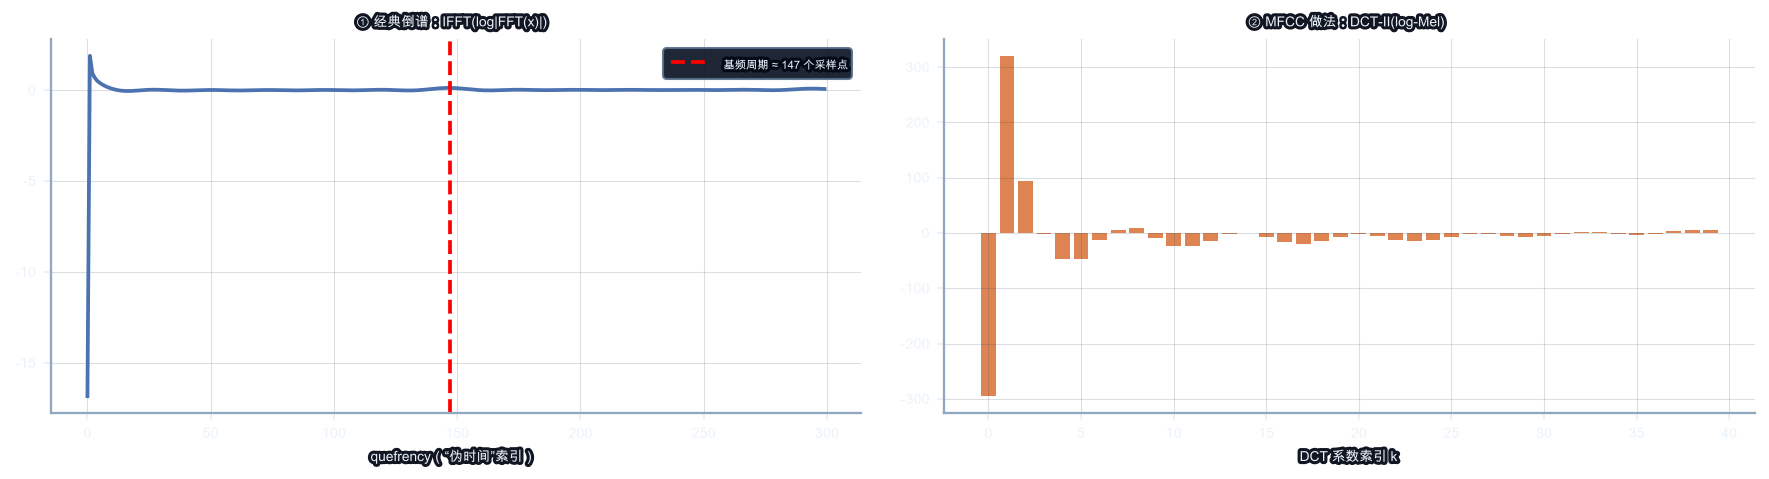

In [2]:
# ═══ 代码演示：真正跑一遍"倒谱" IFFT(log|FFT(x)|)，并对比 MFCC 用的 DCT-II ═══
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.mel import mel_spectrogram, power_to_db
from aurora.audio.mfcc import dct_ii

SR_demo2 = 22050
t2 = np.linspace(0, 0.5, int(SR_demo2 * 0.5), endpoint=False)

# 模拟一个基频 150 Hz 的"浊音"：基频 + 5 个衰减的泛音（越高次泛音越弱）
f0 = 150
sig2 = sum(0.5 ** k * np.sin(2 * np.pi * f0 * (k + 1) * t2) for k in range(6))

# ① 经典"倒谱"三步走：FFT → log|·| → IFFT
spec = np.fft.fft(sig2 * np.hanning(len(sig2)))        # 步骤1：整段信号做 FFT（频谱，复数）
log_mag = np.log(np.abs(spec) + 1e-10)                  # 步骤2：只取幅度，再取 log（乘法拆成加法）
real_cepstrum = np.fft.ifft(log_mag).real               # 步骤3：对 log 谱再做一次逆傅里叶变换，取实部

# ② MFCC 实际做法：Mel 滤波压缩到 40 维 → power_to_db → dct_ii
mel_s2 = mel_spectrogram(sig2, SR_demo2, n_fft=1024, n_mels=40)
log_mel2 = power_to_db(mel_s2[2], top_db=None)           # 取中间一帧，(40,)
mfcc_coeffs = dct_ii(log_mel2, norm="ortho")              # DCT-II，(40,)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(real_cepstrum[:300], color="#4C72B0")
peak_q = SR_demo2 / f0
axes[0].axvline(peak_q, color="red", linestyle="--", label=f"基频周期 ≈ {peak_q:.0f} 个采样点")
axes[0].set_title("① 经典倒谱：IFFT(log|FFT(x)|)", fontsize=11)
axes[0].set_xlabel("quefrency（“伪时间”索引）")
axes[0].legend(fontsize=9)

axes[1].bar(range(40), mfcc_coeffs, color="#DD8452", width=0.8)
axes[1].set_title("② MFCC 做法：DCT-II(log-Mel)", fontsize=11)
axes[1].set_xlabel("DCT 系数索引 k")

plt.tight_layout()
plt.savefig("v1_cepstrum_vs_dct.png", dpi=120)
plt.show()

print(f"① 经典倒谱在 quefrency ≈ {peak_q:.0f} 处出现尖峰 —— 这就是基频周期，")
print("   是从'混合信号'里把'激励（音高）'和'声道（音色）'分开的经典手法。")
print()
print("② MFCC 没有真的做 IFFT，而是：先用 Mel 滤波器把频谱压成 40 个感知相关的 bin")
print("   （这一步本身就是平滑/降维），再对这个已经是实数、非负、只有 40 个点的序列做 DCT-II。")
print()
print("为什么 MFCC 选 DCT-II 而不是真的做 IFFT：")
print("  1) DCT-II 输入输出都是实数——不用像 IFFT 那样处理复数、再手动取 .real；")
print("  2) DCT-II 配合 norm='ortho' 天然正交——逆变换只需转置矩阵，不需要求逆；")
print("  3) 对 Mel 这种已经很短（40 维）的平滑向量，DCT-II 计算量比对整段频谱做 IFFT 小得多。")
print("下面到 TODO 练习前，会用真实的重构误差数字，进一步验证这几点好处。")


## 核心直觉

**频谱的平滑性 → 系数的集中性**

Mel 频谱有 40–80 个 bin，相邻 bin 之间高度相关（频谱包络变化平滑）。
DCT-II 把这种"慢变化"集中到前几个系数，后面的系数几乎是噪声——这就是 MFCC 能用 13 维描述音色的原因。

**倒谱视角**（选读）：原音频是"激励 × 声道"（乘法），取对数后变成"log(激励) + log(声道)"（加法）。DCT-II 类似倒谱，通过逆变换把这两部分分开；但我们只保留前 13 个系数（对应"声道"部分），就足以重建音色。

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import chirp
from aurora.audio.mel import mel_spectrogram, power_to_db
from aurora.audio.mfcc import mfcc, dct_ii

## 🎯 为什么用 DCT-II？（及其公式详解）

### DCT 是什么？

**离散余弦变换（DCT）**是一种把信号分解成"余弦波"的方式。听起来复杂，但直观理解就是：

> **DCT 像"彩虹"分解白光那样，把一个频谱向量分解成若干个"纯净的余弦波"的混合**。

它和傅里叶变换的区别？
- **傅里叶变换**用 `$e^{i\theta} = \cos(\theta) + i\sin(\theta)$`（复数正弦和余弦）
- **DCT**只用余弦（实数），是傅里叶的"简化版"，对实数信号特别友好

---

### DCT-II 公式拆解

```
y[k] = sum_{n=0}^{N-1}  S[n] * cos( pi/N * (n + 0.5) * k )
```

**为什么这个公式能做"能量集中"？** 一步步看：

**1. 为什么选余弦？**

因为余弦是"最光滑的"周期函数，最适合表示频谱这种"缓慢变化"的信号。相比之下，正弦在 0 点是 0，高频分量容易混在一起。

**2. 那个 `(n + 0.5)` 是什么意思？**

想象你有 40 个 Mel bin（0 到 39）。如果直接用 `cos(pi/N * n * k)`，你会在 n=0 处浪费一半的信息。

改成 `cos(pi/N * (n + 0.5) * k)` 就像把采样点移到**每个 bin 的中心**：
- n=0 对应中心位置 0.5
- n=1 对应中心位置 1.5
- ...
- n=39 对应中心位置 39.5

这样利用率更高。

**3. 为什么能量集中在低阶？**

关键观察：频谱包络**通常是光滑的**（相邻 bin 值接近）。

余弦基函数呢？
- k=0：`cos(0) = 1`（常数）—— 捕捉"整体平均能量"
- k=1：`cos(pi/40 * (n+0.5) * 1)` —— 最慢的余弦波，半周期拉伸到整个 40 bin —— 捕捉"低→高的缓慢倾斜"
- k=2：更快的余弦波 —— 捕捉"小山包"形状
- k=13+：非常快的余弦波 —— 只能捕捉"噪声抖动"（频谱本身没那么多细节）

**对于光滑信号，低阶（慢）基函数就能拟合 90%，高阶（快）基函数贡献微乎其微。** ✨

---

### DCT-II 的正交性（预告）

这个 DCT-II 还有个超级重要的性质：**正交**，意思是这些余弦基函数两两互相"垂直"（内积为 0）。

好处？
- 能量守恒：原信号的总"能量"= 所有系数的平方和
- 逆变换简单：用同一套基函数反着乘就能还原

下面立即看到这一点。

## 1. DCT 压缩：能量集中原理

Mel 频谱每帧是一个 40 维向量 `S[m]`（m = 0…39），经 DCT-II 得到系数：

```
y[k] = sum_{n=0}^{N-1}  S[n] * cos( pi/N * (n + 0.5) * k )
```

### 什么是"正交归一化"（`norm="ortho"`）？

上面的公式还没有归一化。加上 `norm="ortho"` 后，会乘上一些权重（scaling factors）：

$$c[k] = w_k \cdot \sum_{n=0}^{N-1} S[n] \cdot \cos\left(\frac{\pi}{N}(n+0.5)k\right)$$

其中：
$$w_0 = \frac{1}{\sqrt{N}}, \quad w_k = \sqrt{\frac{2}{N}} \quad (k \geq 1)$$

**为什么这样缩放？**

#### 正交基的概念（直白版）

想象 3D 空间的三个坐标轴 x、y、z：
- 它们**互相垂直**（垂直 = 正交）
- 它们**长度都是 1**（归一化）
- 任何向量都能用"x 方向多少，y 方向多少，z 方向多少"来描述

DCT 的余弦基函数也一样：加上 `norm="ortho"` 后，这些基函数就变成**互相垂直、长度都是 1 的坐标轴**。

#### 好处：能量守恒 + 逆变换简单

✨ **能量守恒**：原信号的总"能量" = `sum(S[n]²)` = 系数的总能量 = `sum(c[k]²)`

✨ **逆变换简单**：反着乘同一套基函数就能还原 `S = c @ B.T`（B 是基矩阵），不需要求逆矩阵

---

### 常数基函数：为什么 c[0] 是均值？

特别地，`k=0` 时：

$$c[0] = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} S[n] = \frac{1}{\sqrt{N}} \times (\text{均值} \times N) = \sqrt{N} \times \text{均值}(S)$$

所以 `c[0]` 直接反映了这一帧的**总对数能量**（乘以 √N 是为了保证与其他系数在同一个"能量量纲"）。

---

正交归一化后，`k=0` 对应常数基函数，`k=1` 对应最慢余弦……
频谱包络平滑 → 高阶系数（大 k）贡献极小 → 截取前 13 个系数损失信息极少。

## 🧪 为什么一定要先 `power_to_db`？——一个对比实验

前面"背景知识"提过一句话："对数能把乘法拆成加法"。但这跟 DCT 压缩有什么关系？为什么代码里一定要先 `power_to_db`，再 `dct_ii`，直接 `dct_ii(mel_spec)` 不行吗？

**直觉先行**：Mel 频谱的功率值往往差距巨大——响亮的频率成分可能是安静频率成分的几万倍。这种"一个山峰独大、其他几乎是平地"的形状，恰恰是 DCT-II 最不擅长压缩的（还记得吗？DCT 靠"频谱变化缓慢、光滑"才能把能量集中到低阶系数）。取对数会把这种悬殊的数值差距"压平"，让频谱变成一条更光滑的曲线，DCT 才能真正发挥"光滑 → 能量集中"的优势。

光说不练没有说服力，下面直接跑一遍对比实验：不取 log 直接做 DCT，vs 先 `power_to_db` 再做 DCT，看看压缩效果差多少。

In [4]:
# ═══ 对比实验：不取 log 直接做 DCT，vs 先 power_to_db 再做 DCT ═══
import numpy as np
from aurora.audio.io import chirp
from aurora.audio.mel import mel_spectrogram, power_to_db
from aurora.audio.mfcc import dct_ii

SR_pdb, N_MELS_pdb, N_KEEP_pdb = 22050, 40, 13
sig_pdb = chirp(duration=1.0, f0=200, f1=4000, sample_rate=SR_pdb)
mel_pdb = mel_spectrogram(sig_pdb, SR_pdb, n_fft=1024, n_mels=N_MELS_pdb)        # 原始功率谱，(n_frames, 40)
log_mel_pdb = power_to_db(mel_pdb, top_db=None)                                   # 取过 log 的谱


def retention_rate(x, keep=N_KEEP_pdb):
    """算前 keep 个 DCT 系数占全部方差（能量）的百分比。"""
    coeffs = dct_ii(x, norm="ortho")
    var_per_k = np.var(coeffs, axis=0)
    return var_per_k[:keep].sum() / var_per_k.sum() * 100


retention_raw = retention_rate(mel_pdb)        # 直接对原始功率谱做 DCT
retention_log = retention_rate(log_mel_pdb)    # 先取 log 再做 DCT

print(f"原始 Mel 功率谱数值范围：[{mel_pdb.min():.2e}, {mel_pdb.max():.2e}]  ← 最大/最小 ≈ {mel_pdb.max()/max(mel_pdb.min(), 1e-12):.0e} 倍")
print(f"log-Mel（dB）数值范围：  [{log_mel_pdb.min():.1f}, {log_mel_pdb.max():.1f}]  ← 差距只有几十")
print()
print(f"❌ 不取 log，直接 dct_ii(mel_spec)：前 {N_KEEP_pdb} 个系数保留能量 = {retention_raw:.1f}%")
print(f"✅ 先 power_to_db 再 dct_ii：       前 {N_KEEP_pdb} 个系数保留能量 = {retention_log:.1f}%")
assert retention_log > retention_raw, "取 log 后压缩效果应该更好"
print()
print("结论：不取 log 时，数值被少数几个'山峰' bin 主导，DCT 要用更多系数才能描述这种起伏，")
print("      压缩效果差了一大截；先取 log 把数值差距压平，DCT 才能把 40 维有效地浓缩到 13 维。")
print("      这也是人耳感知的规律——响度是按对数（分贝）而不是线性感知的，取 log 让特征更符合听觉。")


原始 Mel 功率谱数值范围：[1.10e-13, 9.09e+04]  ← 最大/最小 ≈ 9e+16 倍
log-Mel（dB）数值范围：  [-100.0, 49.6]  ← 差距只有几十

❌ 不取 log，直接 dct_ii(mel_spec)：前 13 个系数保留能量 = 44.0%
✅ 先 power_to_db 再 dct_ii：       前 13 个系数保留能量 = 96.8%

结论：不取 log 时，数值被少数几个'山峰' bin 主导，DCT 要用更多系数才能描述这种起伏，
      压缩效果差了一大截；先取 log 把数值差距压平，DCT 才能把 40 维有效地浓缩到 13 维。
      这也是人耳感知的规律——响度是按对数（分贝）而不是线性感知的，取 log 让特征更符合听觉。


✅ 观察：能量集中在 k < 13 的左侧，右侧系数接近 0


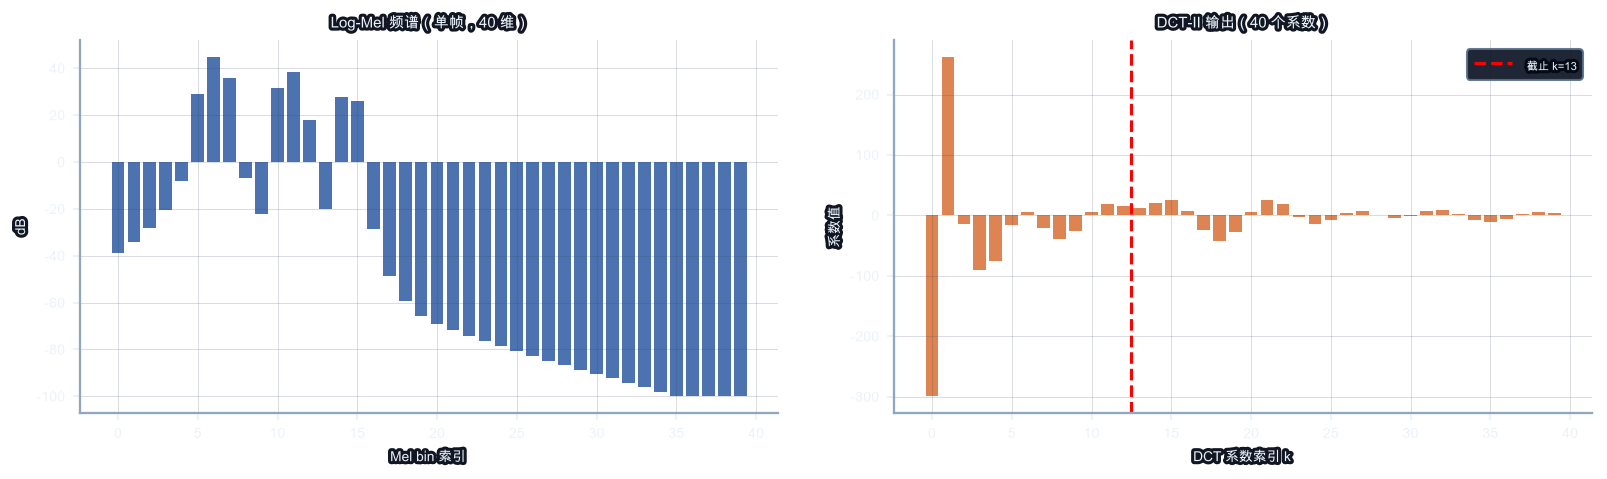

In [5]:
SR = 22050
N_MELS = 40

# 合成一段混合音：基频 440 Hz + 泛音，模拟元音音色
t = np.linspace(0, 1.0, SR, endpoint=False)
signal = (
    0.6 * np.sin(2 * np.pi * 440 * t)
    + 0.3 * np.sin(2 * np.pi * 880 * t)
    + 0.1 * np.sin(2 * np.pi * 1320 * t)
)

# 取单帧 Mel 频谱（取第 10 帧，避开 center 填充影响的首帧）
mel_spec = mel_spectrogram(signal, SR, n_fft=1024, n_mels=N_MELS)
log_mel_frame = power_to_db(mel_spec[10], top_db=None)   # 单帧 log-mel，形状 (40,)  — 与 mfcc.py 一致

# DCT 变换
dct_all = dct_ii(log_mel_frame, norm="ortho")          # 形状 (40,)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(range(N_MELS), log_mel_frame, color="#4C72B0", width=0.8)
axes[0].set_title("Log-Mel 频谱（单帧，40 维）", fontsize=12)
axes[0].set_xlabel("Mel bin 索引")
axes[0].set_ylabel("dB")

axes[1].bar(range(N_MELS), dct_all, color="#DD8452", width=0.8)
axes[1].axvline(12.5, color="red", linestyle="--", linewidth=1.5, label="截止 k=13")
axes[1].set_title("DCT-II 输出（40 个系数）", fontsize=12)
axes[1].set_xlabel("DCT 系数索引 k")
axes[1].set_ylabel("系数值")
axes[1].legend()

plt.tight_layout()
plt.savefig("v1_dct_compression.png", dpi=120)
plt.show()
print("✅ 观察：能量集中在 k < 13 的左侧，右侧系数接近 0")

✅ 观察：k=0 是平坦的（常数），k=1 缓慢波动，k=12 快速振荡。
   光滑频谱用前几个基函数就能拟合，高阶系数接近 0。


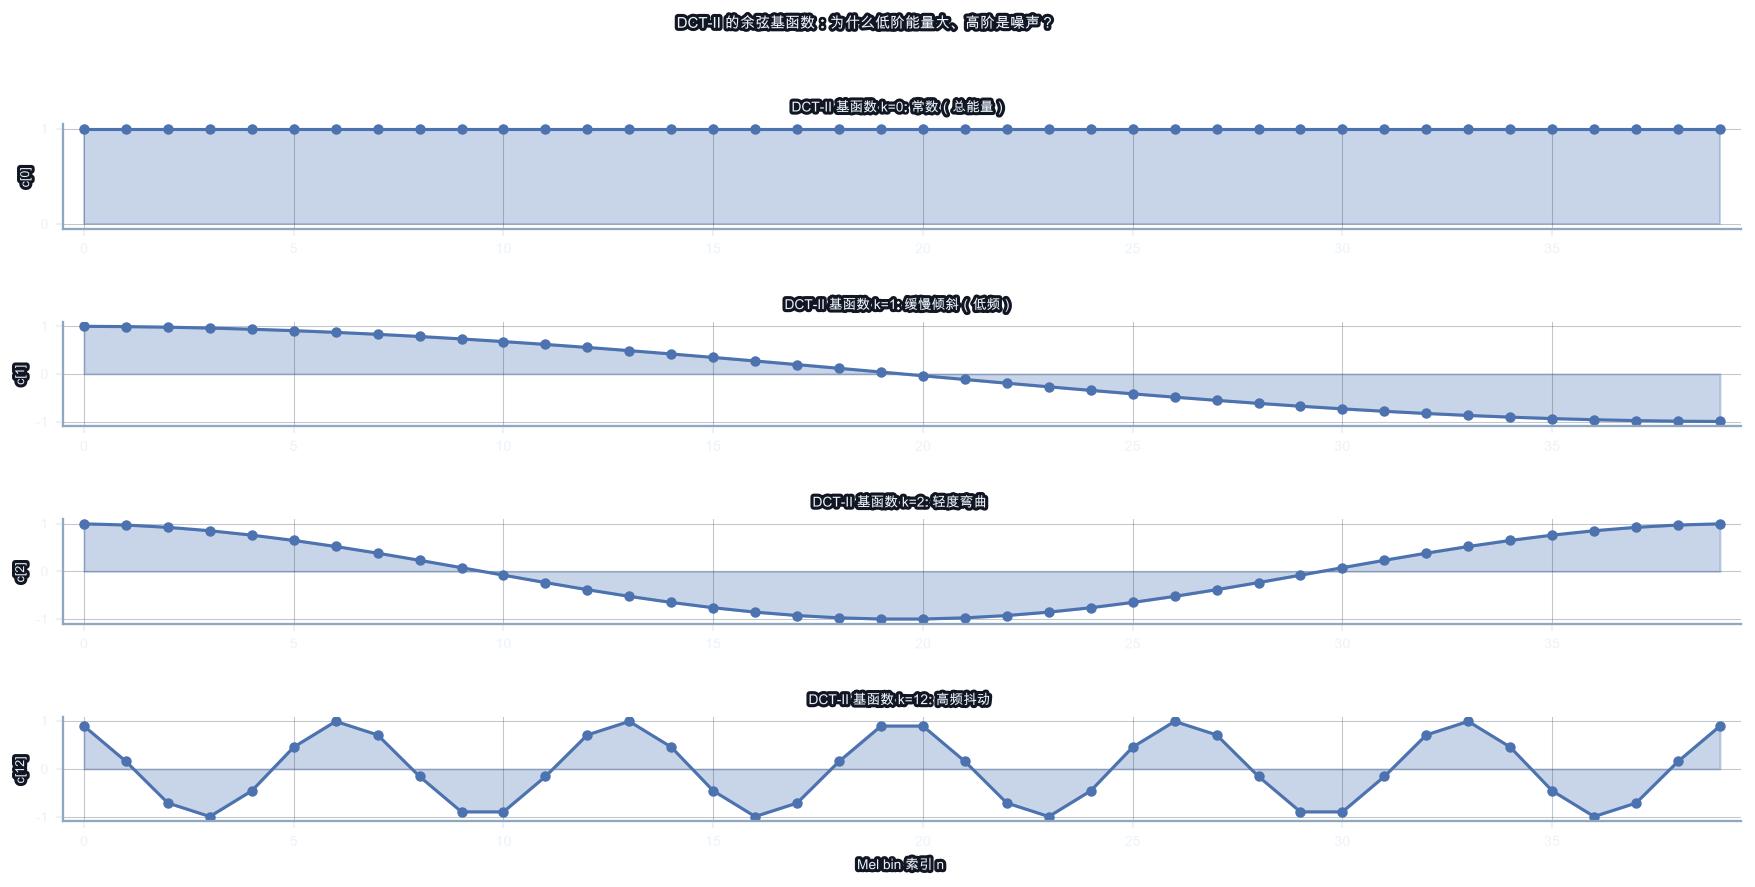

In [6]:
# ─ DCT-II 基函数可视化：看看为什么能能量集中 ─────
N_MELS = 40
k_arr = np.arange(N_MELS)
n_arr = np.arange(N_MELS)

# 构造几个 DCT-II 基函数
fig, axes = plt.subplots(4, 1, figsize=(12, 6))

basis_k = [0, 1, 2, 12]  # 第 0、1、2、12 阶基函数

for ax, k in zip(axes, basis_k):
    # 无正交化时的余弦基
    basis_raw = np.cos(np.pi / N_MELS * (n_arr + 0.5) * k)
    ax.plot(n_arr, basis_raw, 'o-', color="#4C72B0", markersize=4, linewidth=1.5, label=f'k={k} (余弦波)')
    ax.fill_between(n_arr, 0, basis_raw, alpha=0.3, color="#4C72B0")
    ax.set_ylabel(f'c[{k}]', fontsize=10)
    ax.set_title(
        f'DCT-II 基函数 k={k}: ' +
        (['常数（总能量）', '缓慢倾斜（低频）', '轻度弯曲', '高频抖动'][k if k < 3 else 3]),
        fontsize=11
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, N_MELS - 0.5)

axes[-1].set_xlabel('Mel bin 索引 n')
fig.suptitle('DCT-II 的余弦基函数：为什么低阶能量大、高阶是噪声？', fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig("v1_dct_basis.png", dpi=120)
plt.show()

print(f"✅ 观察：k=0 是平坦的（常数），k=1 缓慢波动，k=12 快速振荡。")
print(f"   光滑频谱用前几个基函数就能拟合，高阶系数接近 0。")


## 🧩 眼见为实：真的能用余弦"拼"出频谱曲线吗？

上面画出了单个基函数的样子，但"c[1] 编码倾斜、c[2] 编码弯曲"这种说法终究是空口白话。这里我们做一件很实在的事：把系数一个个乘回它对应的基函数，加起来，看看重构出来的曲线离真实的 log-Mel 频谱有多近——这也是回答"频谱包络"是什么的最直接方式：它就是连接 40 个 Mel bin 数值的那条光滑曲线，DCT 就是在用几条余弦波去逼近这条曲线。

观察 k=0：只有一条水平线——只捕捉了'总体音量'（对应 c[0] = 总对数能量）。
观察 k=1：加入第一条缓慢余弦后，曲线开始'倾斜'——c[1] 控制的正是这个整体倾斜方向（正/负对应低频/高频主导）。
观察 k=2：再加入一条弯一点的余弦，曲线出现'拱形'——c[2] 控制这种粗略的弯曲（拱起或凹陷）。
观察 k=12 vs k=39：到 k=12 时曲线已经和真实频谱几乎重合；再加到 k=39 几乎没有变化——
      这就是'高阶系数几乎不携带信息'的直接证据，也是 MFCC 只保留前 13 维的原因。

'频谱包络'指的就是这条连接 40 个 Mel bin 数值的光滑曲线；DCT 做的事情，
      就是用少数几条不同'弯曲程度'的余弦波去逼近这条曲线。


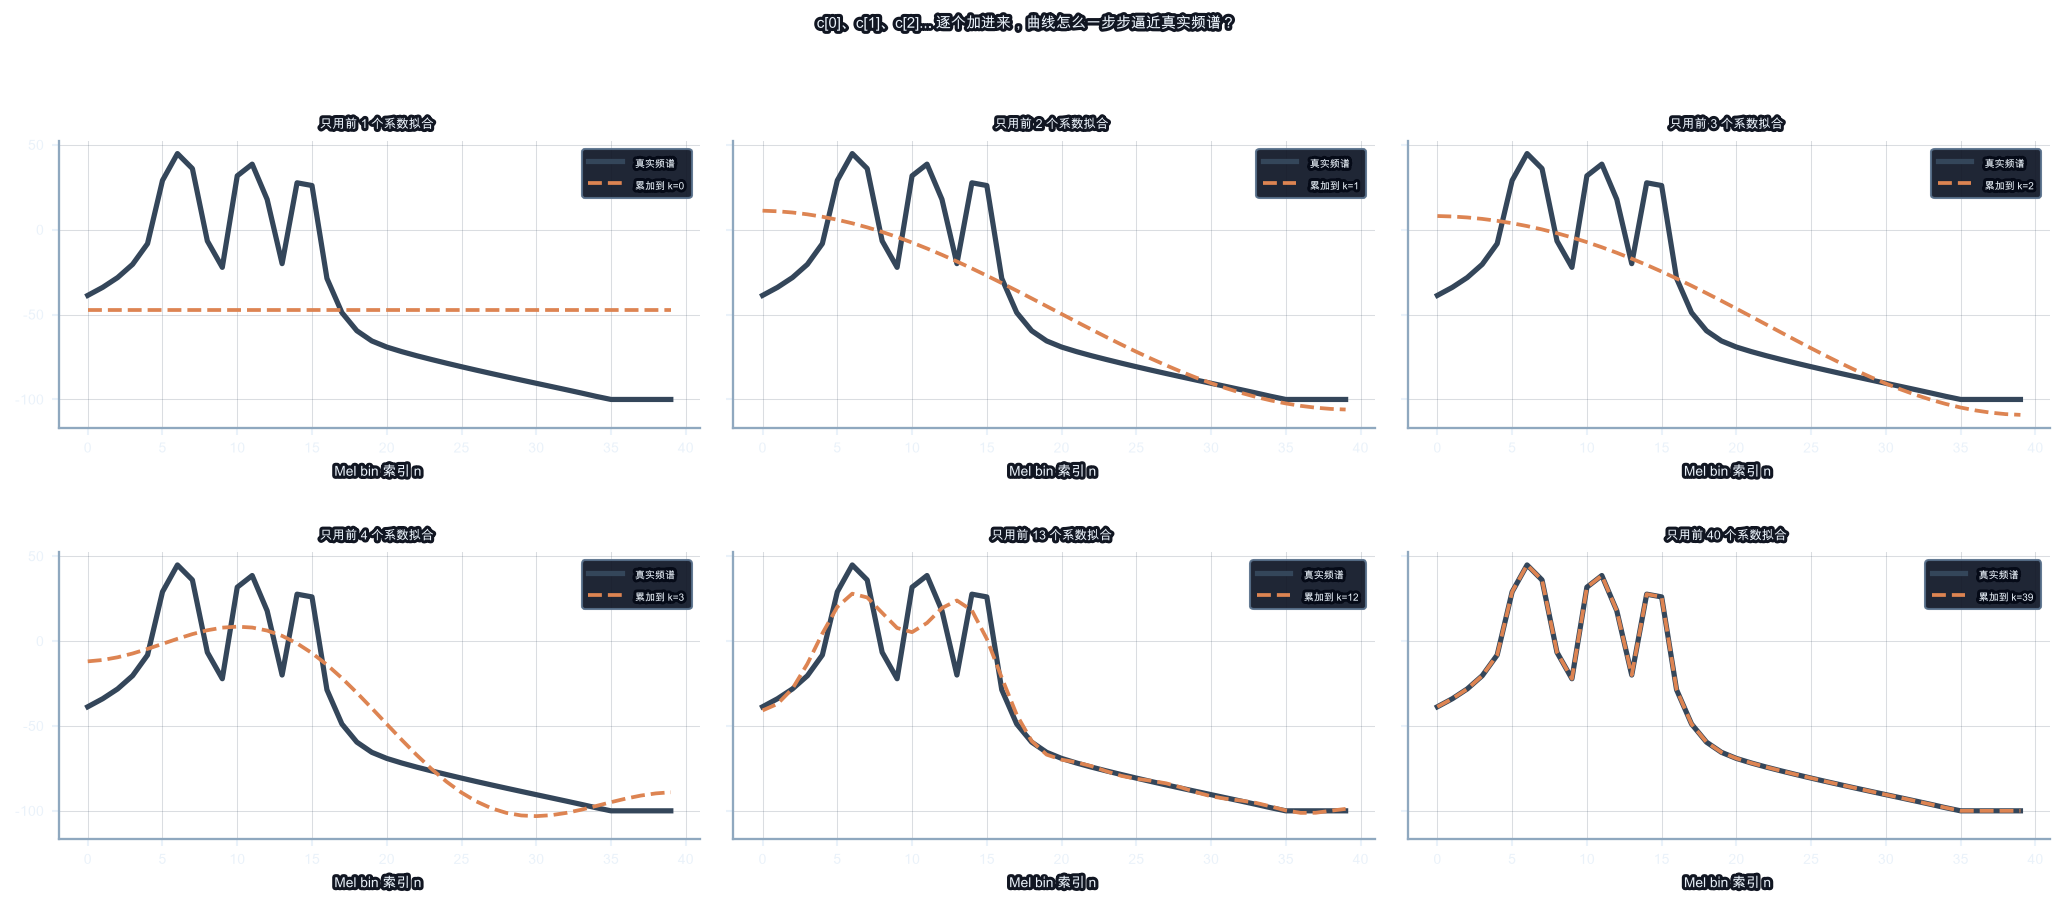

In [7]:
# ═══ 演示：c[0]·基函数0 + c[1]·基函数1 + c[2]·基函数2 + ... 逐渐拼出真实频谱 ═══
n_arr = np.arange(N_MELS)
w0_fit = 1.0 / np.sqrt(N_MELS)
wk_fit = np.sqrt(2.0 / N_MELS)


def basis_k(k):
    """第 k 个 DCT-II 基函数（已做 ortho 缩放），长度 N_MELS。"""
    raw = np.cos(np.pi / N_MELS * (n_arr + 0.5) * k)
    return raw * (w0_fit if k == 0 else wk_fit)


# log_mel_frame、dct_all 来自前面"DCT 压缩"那个 cell（同一帧数据，直接复用）
approx_orders = [0, 1, 2, 3, 12, 39]  # 累加到第几阶系数为止

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
for ax, K in zip(axes.flat, approx_orders):
    recon = sum(dct_all[k] * basis_k(k) for k in range(K + 1))
    ax.plot(n_arr, log_mel_frame, color=plt.rcParams["grid.color"], lw=2.5, label="真实频谱")
    ax.plot(n_arr, recon, color="#DD8452", lw=1.8, ls="--", label=f"累加到 k={K}")
    ax.set_title(f"只用前 {K + 1} 个系数拟合", fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel("Mel bin 索引 n")

fig.suptitle("c[0]、c[1]、c[2]... 逐个加进来，曲线怎么一步步逼近真实频谱？", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("v1_basis_fit_demo.png", dpi=120)
plt.show()

print("观察 k=0：只有一条水平线——只捕捉了'总体音量'（对应 c[0] = 总对数能量）。")
print("观察 k=1：加入第一条缓慢余弦后，曲线开始'倾斜'——c[1] 控制的正是这个整体倾斜方向（正/负对应低频/高频主导）。")
print("观察 k=2：再加入一条弯一点的余弦，曲线出现'拱形'——c[2] 控制这种粗略的弯曲（拱起或凹陷）。")
print("观察 k=12 vs k=39：到 k=12 时曲线已经和真实频谱几乎重合；再加到 k=39 几乎没有变化——")
print("      这就是'高阶系数几乎不携带信息'的直接证据，也是 MFCC 只保留前 13 维的原因。")
print()
print("'频谱包络'指的就是这条连接 40 个 Mel bin 数值的光滑曲线；DCT 做的事情，")
print("      就是用少数几条不同'弯曲程度'的余弦波去逼近这条曲线。")


## 📐 系数含义的几何直觉

DCT 的每个系数 `c[k]` 衡量的是"输入信号与第 k 个余弦基函数的相似度"。不同的 k 对应不同的余弦频率：

| k 值 | 基函数形状 | 对 Mel 频谱的影响 | 物理含义 |
|------|----------|---------|---------|
| k=0 | 常数（平坦） | 整体平均 | **总对数能量**：c[0] = √N × mean(S)，大 = 响 |
| k=1 | 半周期余弦（缓慢） | 低频 bin 权重↑，高频权重↓ | **频谱倾斜**：c[1] > 0 = 低频主导，c[1] < 0 = 高频主导 |
| k=2 | 一周期余弦（稍快） | "中间高，两端低"的拱形 | **频谱弯曲**：c[2] > 0 = 类似中频共振（如 /a/ 音）|
| k=3..12 | 更高频余弦（快速） | 越来越细致的共振峰结构 | **细粒度共振峰**：不同元音的 c[3..12] 值差异最大 |
| k≥13 | 高频抖动（极快） | 只捕捉噪声细节，对音质没用 | **噪声**：通常丢弃 |

（想直接"看见"这张表格里说的"倾斜""弯曲"到底长什么样？往前翻一个 cell——那里用真实频谱数据把 c[0]、c[1]、c[2] 一步步加回去，画出了拟合过程。）

### 先补一点声学背景：什么是"共振"？

你有没有试过对着空玻璃瓶口吹气，瓶子会发出"呜——"的声音？瓶子本身不发声，但瓶内的空气柱会在某个特定频率上被"放大"成一个音高——这就是**共振**：一个空腔会把某些频率的振动放大，把其他频率衰减掉。瓶子越大/越粗，共振的频率越低；换一个形状，共振频率也跟着变。

人的声道（喉咙、口腔、鼻腔）就是一根形状会不断变化的"瓶子"。声带发出的声音（激励，包含很多频率成分）经过声道时，某几个特定频率会被声道形状放大——这些被放大的频率峰，就叫**共振峰（formant）**。舌头、嘴唇、下巴的位置一变，声道形状就变，共振峰的位置也跟着变——这正是我们能用同一副嗓子"捏"出不同元音（/a/、/i/、/u/...）的物理原因。

**共振峰（formant）**具体是什么？ 在元音中，声道共振会强化某些频率。比如 /a/ 音有 3 个共振峰（大约 730, 1090, 2440 Hz），/i/ 音有不同的位置。DCT 的中阶系数（3-12）就是在编码这些个性化结构。

---

## 2. 各阶系数的物理含义

| 系数 | 基函数形状 | 物理含义 |
|------|-----------|---------|
| `c[0]` | 常数（全1） | log-mel 频谱的均值 = 帧总对数能量 |
| `c[1]` | 半周期余弦 | 频谱包络的低频倾斜（高频能量 vs 低频能量） |
| `c[2]` | 一周期余弦 | 包络的"弓形"弯曲 |
| `c[3..12]` | 更高频余弦 | 越来越细致的共振峰（formant）结构 |
| `c[13+]` | 高频抖动 | 噪声，通常丢弃 |

关键公式（`norm="ortho"`，`k=0`）：

```
c[0] = sqrt(1/N) * sum_{n} S[n]   # 即 N 个 Mel bin 的均值（乘以 sqrt(N)）
```

c[0] 随音量变化，做说话人无关识别时常将其去掉或用 **CMN（倒谱均值归一化，Cepstral Mean Normalization）**消除。

CMN 的思想：c[0] 反映整体音量，而音量因人而异、因环境而异（麦克风不同、距离不同）。如果训练说话人识别模型时不消除 c[0]，模型会学到"音量特征"而非"声纹特征"。CMN 的做法就是对 c[0] 减去其在整段语音中的均值，让 c[0] 归零，强制模型关注其他系数（c[1]、c[2] 等）。

**用"瓶子"类比理解 CMN**：同一个瓶子，你可以吹得轻一点或重一点，声音的音量（大小）会变，但瓶子的共振频率（决定"是哪种声音"的关键特征）不会变——音量只是"吹的力气"，不是瓶子的"形状信息"。c[0] 就相当于"吹的力气"：它反映音量，但不反映"声道形状"（也就是不反映音色本身）。CMN 做的事情，就是把这个"力气大小"的差异抹掉，只保留"瓶子形状"（声道特征）的信息，这样模型才不会被说话人音量大小、麦克风远近这些无关因素带偏。

✅ 观察：c[0] 反映总能量；c[1] 正 → 低频主导，c[1] 负 → 高频主导


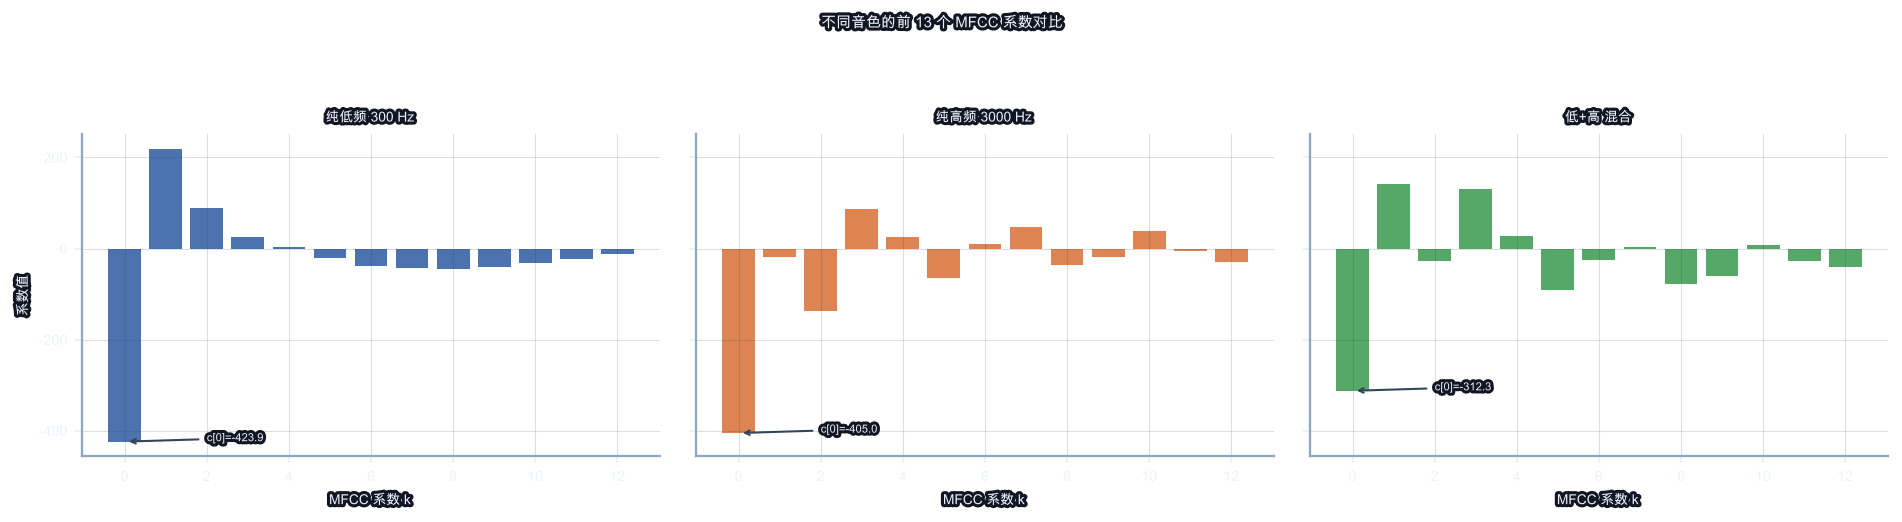

In [8]:
# 对比三种音色：纯正弦 vs 共振峰聚集在高频 vs chirp
t = np.linspace(0, 1.0, SR, endpoint=False)

sig_low  = np.sin(2 * np.pi * 300 * t)                          # 纯低频
sig_high = np.sin(2 * np.pi * 3000 * t)                         # 纯高频
sig_mix  = 0.5 * sig_low + 0.5 * sig_high                       # 低+高

signals  = [sig_low, sig_high, sig_mix]
labels   = ["纯低频 300 Hz", "纯高频 3000 Hz", "低+高 混合"]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)

for ax, sig, label, color in zip(axes, signals, labels, colors):
    mel_s = mel_spectrogram(sig, SR, n_fft=1024, n_mels=N_MELS)
    lm = power_to_db(mel_s[10], top_db=None)
    c = dct_ii(lm, norm="ortho")[:13]
    ax.bar(range(13), c, color=color, width=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("MFCC 系数 k")
    if ax is axes[0]:
        ax.set_ylabel("系数值")
    # 标注 c0
    ax.annotate(f"c[0]={c[0]:.1f}", xy=(0, c[0]), xytext=(2, c[0]+1),
                arrowprops=dict(arrowstyle="->", color=plt.rcParams["grid.color"]), fontsize=9)

fig.suptitle("不同音色的前 13 个 MFCC 系数对比", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("v1_mfcc_timbre.png", dpi=120)
plt.show()
print("✅ 观察：c[0] 反映总能量；c[1] 正 → 低频主导，c[1] 负 → 高频主导")

## 🔋 什么是"能量"与"方差"？

在信号处理中，**能量**通常定义为：

$$E = \sum_{n=0}^{N-1} x[n]^2$$

这与物理中的"动能"`(1/2)mv²` 的概念相似——数值越大，"能量"越强。

### 为什么用"方差"衡量系数的重要性？

对于多帧音频，每个 DCT 系数在时间轴上会变化。比如：
- **静音帧**的 c[0]、c[1] 都很小
- **响亮帧**的 c[0]、c[1] 都很大

**方差** = 一个系数在不同帧之间的"波动幅度"：

$$\text{var}(c[k]) = \frac{1}{T} \sum_{t=0}^{T-1} (c[k,t] - \text{mean}(c[k]))^2$$

**为什么方差大 = 这个系数重要？**

- **方差大** → 这个系数在不同帧间变化明显 → 承载了丰富的**音色信息**（分辨不同音素）
- **方差小** → 这个系数在所有帧间都接近常数 → 冗余的**噪声信息**（所有音都一样）

机器学习的角度：如果你要训练一个说话人识别模型，方差大的系数更能帮助模型区分不同的人声，所以更"重要"。

### 对"多帧"数据求方差：广播的力量

代码里有：
```python
log_mel_all.shape = (n_frames, 40)  # 比如 (100 帧, 40 Mel bin)
dct_all_frames.shape = (100, 40)
var_per_bin = np.var(dct_all_frames, axis=0)  # axis=0 是跨时间求方差
# 结果 var_per_bin.shape = (40,)  # 每个系数的方差
```

`axis=0` 的意思：**沿着时间轴压缩**，对于每一列（每个系数编号 k），计算其在时间上的波动。

---

## 参数实验：能量集中度量化

**参数**：`N_MELS = 40`，截取 `n_mfcc = 13`

**预期现象**：
- 前 13 个系数的方差之和 >> 后 27 个系数的方差之和
- 能量保留率（前13维 / 全40维的功率比）应 > 95%

调整 `N_MELS` 到 80 或改变信号复杂度（chirp vs 纯音），观察能量保留率如何变化。

## 📦 插曲：NumPy 的"广播"（broadcasting）是什么？

马上要处理的数据是 `(n_frames, 40)` 的二维数组——每一行是一帧音频的 log-Mel 频谱。代码里会直接写 `dct_ii(log_mel_all, norm="ortho")`，不需要写 `for` 循环去一帧一帧处理。这是怎么做到的？

**如果你只会 `for` 循环**，可能会这样写：

```python
results = []
for row in log_mel_all:          # 一行一行地处理
    results.append(dct_ii(row, norm="ortho"))
results = np.array(results)
```

NumPy 提供了更快、更简洁的方式，核心技巧叫**广播（broadcasting）**：让"形状不同"的数组之间也能直接做运算，NumPy 会自动把维度对齐、重复，不需要你手写循环。

### 小例子：给二维矩阵的每一行加上同一个向量

这个例子跟 DCT 完全无关，先建立直觉：

```python
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])          # 形状 (3, 3)
v = np.array([10, 100, 1000])       # 形状 (3,)

print(M + v)
# NumPy 自动把 v "复制"成 3 行，每一行都跟 M 的一行对齐，然后逐元素相加
# 不需要写 for 循环，也不需要手动 np.tile(v, (3, 1))
```

### `axis` 参数：告诉 NumPy 沿着哪个方向"压缩"

```python
print("按行求和 (axis=1)：", M.sum(axis=1))   # 每一行加起来，结果形状 (3,)
print("按列求和 (axis=0)：", M.sum(axis=0))   # 每一列加起来，结果形状 (3,)
```

记忆口诀：**`axis=0` 是"跨行"操作（结果里行这个维度消失了），`axis=1` 是"跨列"操作（结果里列这个维度消失了）**。后面"能量与方差"那一节用的是 `np.var(dct_all_frames, axis=0)`，就是"跨帧（跨行）求方差"——把很多帧叠在一起，看每一个系数在不同帧之间的波动，结果留下 40 个系数各自的方差。

### `dct_ii` 是怎么"自动"逐行处理的？

打开 `aurora.audio.mfcc.dct_ii` 的源码，关键的一行是：

```python
y = x @ basis.T   # x: (..., N)，basis.T: (N, N)
```

`@` 是矩阵乘法。如果 `x` 是一维的（单帧，形状 `(40,)`），这就是"向量 × 矩阵"，结果还是一维。如果 `x` 是二维的（多帧，形状 `(n_frames, 40)`），矩阵乘法会自动把它当成"许多行向量分别乘同一个矩阵"——每一行独立做同样的变换，`for` 循环被矩阵乘法一次性"打包"完成了。

紧接着的 `y = y * scale`（`scale` 形状 `(40,)`）就是标准的广播：一个 `(n_frames, 40)` 的结果乘以一个 `(40,)` 的向量，NumPy 自动把 `scale` "摊"到每一行上，逐元素相乘。

**一句话总结**：不管输入是一帧还是一万帧，`dct_ii` 内部代码完全不用改——这就是矩阵乘法（处理"逐行"）和广播（处理"逐元素缩放"）配合的威力。下面用一个小实验验证这一点。

In [9]:
# ═══ 验证：手写 for 循环 vs dct_ii 直接处理二维数组，结果完全一样 ═══
from aurora.audio.mfcc import dct_ii

demo_frames = np.random.default_rng(0).standard_normal((5, 40))  # 假装 5 帧、40 维

loop_result = np.array([dct_ii(row, norm="ortho") for row in demo_frames])
vectorized_result = dct_ii(demo_frames, norm="ortho")

print("for 循环结果形状：      ", loop_result.shape)
print("直接传 2D 数组的结果形状：", vectorized_result.shape)
print("两者是否完全一致：       ", np.allclose(loop_result, vectorized_result))


for 循环结果形状：       (5, 40)
直接传 2D 数组的结果形状： (5, 40)
两者是否完全一致：        True


✅ N_MELS=40，保留前 13 维：
   前 13 系数方差和 = 44306.8802
   后 27 系数方差和 = 1469.8641
   能量保留率 = 96.8%


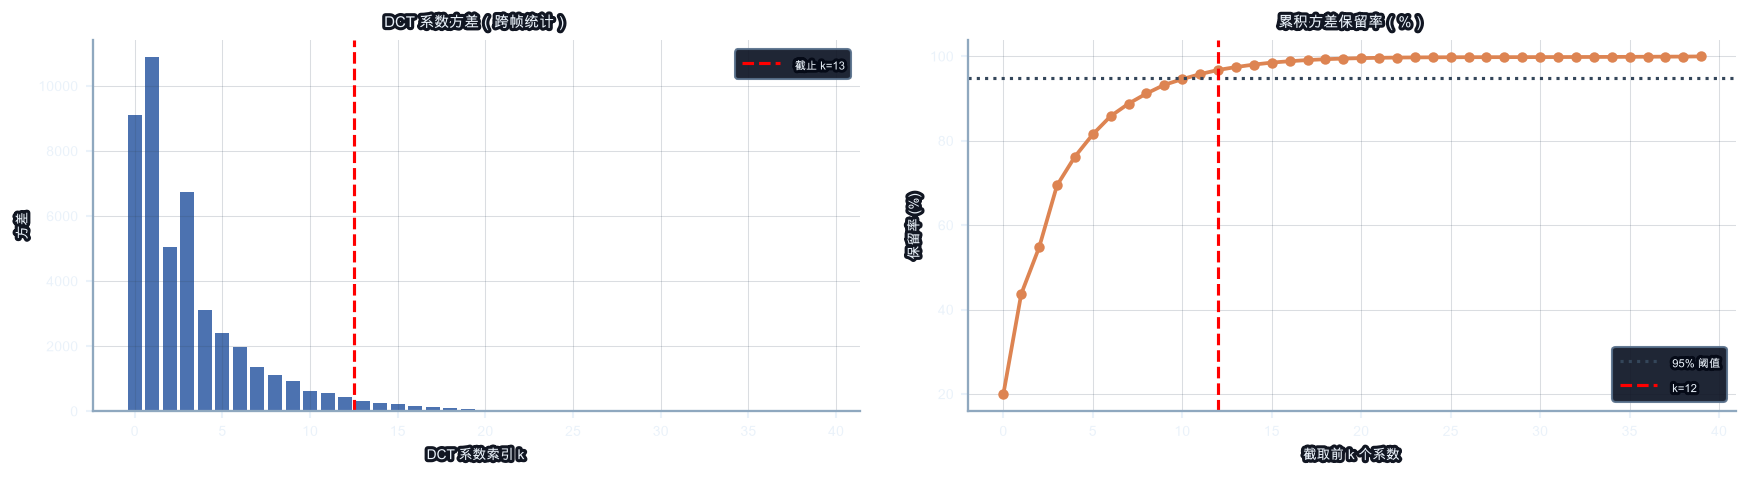

In [10]:
# 注意：这段代码展示了 NumPy 的"广播"（broadcasting）能力
# log_mel_all 是 (n_frames, N_MELS) 的二维数组
# dct_ii() 会对"每一行"独立做 DCT，结果还是 (n_frames, N_MELS)
# 这样的批量处理省去了显式 for 循环，是 NumPy 的核心优势

SR = 22050
N_MELS = 40
N_KEEP = 13

# 用一段 chirp 信号（频谱更丰富，更难压缩）
t = np.linspace(0, 1.0, SR, endpoint=False)
sig_chirp = chirp(duration=1.0, f0=200, f1=4000, sample_rate=SR)

mel_s = mel_spectrogram(sig_chirp, SR, n_fft=1024, n_mels=N_MELS)

# 对所有帧做 DCT，计算每个 bin 的方差
log_mel_all = power_to_db(mel_s, top_db=None)   # (n_frames, N_MELS) — 与 mfcc.py 一致
dct_all_frames = dct_ii(log_mel_all, norm="ortho")  # (n_frames, N_MELS)

var_per_bin = np.var(dct_all_frames, axis=0)  # (N_MELS,)
power_total  = var_per_bin.sum()
power_kept   = var_per_bin[:N_KEEP].sum()
retention    = power_kept / power_total * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# 各系数方差
axes[0].bar(range(N_MELS), var_per_bin, color="#4C72B0", width=0.8)
axes[0].axvline(N_KEEP - 0.5, color="red", linestyle="--", lw=1.5, label=f"截止 k={N_KEEP}")
axes[0].set_title("DCT 系数方差（跨帧统计）", fontsize=12)
axes[0].set_xlabel("DCT 系数索引 k")
axes[0].set_ylabel("方差")
axes[0].legend()

# 累积能量保留率
cumulative = np.cumsum(var_per_bin) / power_total * 100
axes[1].plot(range(N_MELS), cumulative, marker="o", markersize=4, color="#DD8452")
axes[1].axhline(95, color=plt.rcParams["grid.color"], linestyle=":", lw=1.5, label="95% 阈值")
axes[1].axvline(N_KEEP - 1, color="red", linestyle="--", lw=1.5, label=f"k={N_KEEP-1}")
axes[1].set_title("累积方差保留率（%）", fontsize=12)
axes[1].set_xlabel("截取前 k 个系数")
axes[1].set_ylabel("保留率 (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("v1_energy_retention.png", dpi=120)
plt.show()

print(f"✅ N_MELS={N_MELS}，保留前 {N_KEEP} 维：")
print(f"   前 {N_KEEP} 系数方差和 = {power_kept:.4f}")
print(f"   后 {N_MELS-N_KEEP} 系数方差和 = {power_total - power_kept:.4f}")
print(f"   能量保留率 = {retention:.1f}%")
assert retention > 80.0, f"能量保留率 {retention:.1f}% 低于预期（应 > 80%）"


MFCC 矩阵形状：(173, 13)  -> (n_frames, n_mfcc)
✅ 完整 MFCC 链路验证：mfcc() 端到端输出已可视化


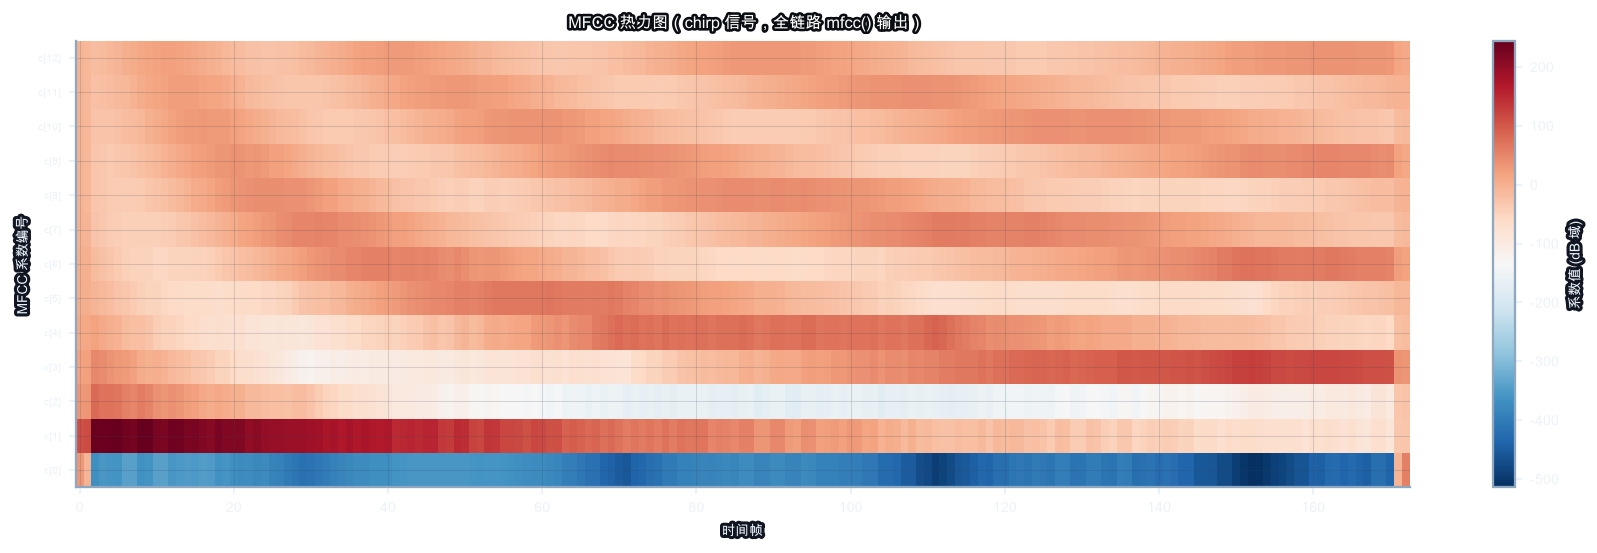

In [11]:
# MFCC 全链路演示：mfcc() 热力图
# 完整链路：mel_spectrogram -> power_to_db -> dct_ii -> [:, :n_mfcc]
SR_demo = 22050
N_MFCC = 13

# chirp 信号：频率随时间变化，MFCC 热力图更有代表性
sig_demo = chirp(duration=2.0, f0=200, f1=4000, sample_rate=SR_demo)

# 调用 aurora 完整 mfcc() 函数
mfcc_matrix = mfcc(sig_demo, SR_demo, n_mfcc=N_MFCC, n_fft=1024, n_mels=40)  # (n_frames, 13)

print(f'MFCC 矩阵形状：{mfcc_matrix.shape}  -> (n_frames, n_mfcc)')

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    mfcc_matrix.T,           # 转置：y 轴 = 系数编号，x 轴 = 时间帧
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    cmap='RdBu_r'
)
ax.set_title('MFCC 热力图（chirp 信号，全链路 mfcc() 输出）', fontsize=13)
ax.set_xlabel('时间帧')
ax.set_ylabel('MFCC 系数编号')
ax.set_yticks(range(N_MFCC))
ax.set_yticklabels([f'c[{k}]' for k in range(N_MFCC)], fontsize=8)
fig.colorbar(im, ax=ax, label='系数值 (dB 域)')
plt.tight_layout()
plt.show()
print('✅ 完整 MFCC 链路验证：mfcc() 端到端输出已可视化')

## 📏 数字说话：DCT-II 重构 vs "直接做 DFT/IFFT" 重构，误差差多少？

前面用倒谱演示解释了"为什么 MFCC 选 DCT-II 而不是真的做 IFFT"，这里用具体的重构误差数字来验证——马上要做的 TODO 练习正是这个实验的"手动版"，这里先看一遍完整流程长什么样。

**实验设计**：把同一帧 log-Mel 频谱（40 维）分别用两种方法压缩到"差不多 13 个数"再重构回 40 维，比较谁的重构误差更小：
- **方法一（DCT-II，MFCC 的做法）**：正向 DCT-II 得到 40 个系数，只保留前 13 个，其余置零，再做逆变换。
- **方法二（真的做 DFT/IFFT）**：正向做实数 FFT（`np.fft.rfft`），只保留前 7 个复数频段（1 个直流 + 6 对复数的实部虚部 ≈ 13 个自由度），其余置零，再用 `np.fft.irfft` 逆变换回 40 维。

两种方法保留的"自由度"（能存的独立数字个数）大致相同，这样比较才公平。

DCT-II 截断重构，平均 RMS 误差 = 3.82 dB
DFT/IFFT 截断重构，平均 RMS 误差 = 5.13 dB

为什么 DCT-II 误差更小？关键在于'边界'：
DFT 隐含假设信号是'首尾相连、周期重复'的——如果 log-Mel 频谱第 0 个值和第 39 个值差很多，
硬接在一起就会出现一个'断崖'，DFT 要花很多高频系数去描述这个断崖，截断后误差就大。
DCT-II 的 (n+0.5) 相当于把信号'对称镜像'后再展开，天然首尾平滑衔接，没有断崖，
所以少数几个低阶系数就能把整条曲线描述得很好——这正是 MFCC 选 DCT-II 的核心原因。


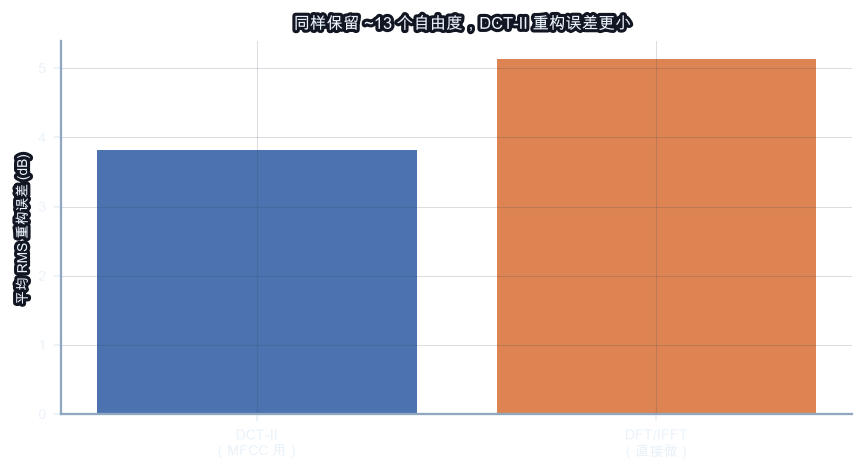

In [12]:
# ═══ 量化对比：DCT-II 截断重构 vs DFT/IFFT 截断重构，谁的误差更小？ ═══
SR_cmp, N_MELS_cmp, N_KEEP_cmp = 22050, 40, 13
sig_cmp = chirp(duration=1.0, f0=200, f1=4000, sample_rate=SR_cmp)
mel_cmp = mel_spectrogram(sig_cmp, SR_cmp, n_fft=1024, n_mels=N_MELS_cmp)
log_mel_cmp = power_to_db(mel_cmp, top_db=None)   # (n_frames, 40)

# 手工构建 DCT-II 正交基矩阵 D（跟 dct_ii 源码里的公式完全一样，这里现算一遍方便对照）
k_arr = np.arange(N_MELS_cmp)
n_arr = np.arange(N_MELS_cmp)
D_cmp = np.cos(np.pi / N_MELS_cmp * np.outer(k_arr, n_arr + 0.5))
D_cmp[0] *= 1.0 / np.sqrt(N_MELS_cmp)
D_cmp[1:] *= np.sqrt(2.0 / N_MELS_cmp)

errs_dct, errs_dft = [], []
for idx in range(5, 30):  # 用连续 25 帧做统计，避免单帧巧合
    frame = log_mel_cmp[idx]

    # 方法一：DCT-II 截断重构（正交矩阵：转置即逆，D.T == D^{-1}）
    c_full = D_cmp @ frame
    c_trunc = c_full.copy()
    c_trunc[N_KEEP_cmp:] = 0.0
    recon_dct = D_cmp.T @ c_trunc
    errs_dct.append(np.sqrt(np.mean((recon_dct - frame) ** 2)))

    # 方法二：真的做 DFT/IFFT 截断重构（保留差不多同样多的自由度）
    F_full = np.fft.rfft(frame)
    F_trunc = F_full.copy()
    F_trunc[7:] = 0.0                                     # 1 个直流 + 6 对复数 ≈ 13 个自由度
    recon_dft = np.fft.irfft(F_trunc, n=N_MELS_cmp)
    errs_dft.append(np.sqrt(np.mean((recon_dft - frame) ** 2)))

print(f"DCT-II 截断重构，平均 RMS 误差 = {np.mean(errs_dct):.2f} dB")
print(f"DFT/IFFT 截断重构，平均 RMS 误差 = {np.mean(errs_dft):.2f} dB")
assert np.mean(errs_dct) < np.mean(errs_dft), "DCT-II 应该比直接做 DFT/IFFT 误差更小"
print()
print("为什么 DCT-II 误差更小？关键在于'边界'：")
print("DFT 隐含假设信号是'首尾相连、周期重复'的——如果 log-Mel 频谱第 0 个值和第 39 个值差很多，")
print("硬接在一起就会出现一个'断崖'，DFT 要花很多高频系数去描述这个断崖，截断后误差就大。")
print("DCT-II 的 (n+0.5) 相当于把信号'对称镜像'后再展开，天然首尾平滑衔接，没有断崖，")
print("所以少数几个低阶系数就能把整条曲线描述得很好——这正是 MFCC 选 DCT-II 的核心原因。")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["DCT-II\n（MFCC 用）", "DFT/IFFT\n（直接做）"], [np.mean(errs_dct), np.mean(errs_dft)],
       color=["#4C72B0", "#DD8452"])
ax.set_ylabel("平均 RMS 重构误差 (dB)")
ax.set_title("同样保留 ~13 个自由度，DCT-II 重构误差更小")
plt.tight_layout()
plt.savefig("v1_dct_vs_dft_recon_error.png", dpi=120)
plt.show()


## 📚 正交矩阵与逆变换（为 TODO 准备）

### 什么是"正交基矩阵"？

假设你有 N 个 DCT 基函数（每个基函数是一个长度为 N 的向量）。把它们排成一个矩阵：

$$D = \begin{bmatrix}
\text{基函数 0} \\
\text{基函数 1} \\
\vdots \\
\text{基函数 N-1}
\end{bmatrix} \quad \text{形状：(N, N)}$$

每一行是一个基函数，比如：
- 行 0：`[cos(0), cos(0), ..., cos(0)]` = `[1, 1, ..., 1]`（常数）
- 行 1：`[cos(π/N×0.5), cos(π/N×1.5), ..., cos(π/N×(N-0.5))]`（缓慢余弦）
- ...

**"正交"**是什么意思？任意两行之间的内积为 0（即"垂直"）。
**"归一化"**是什么意思？每行本身的内积是 1（即"长度为 1"）。

### 一个简单例子：2D 坐标系

想象二维空间的坐标系，两个基向量是：
$$\mathbf{e}_x = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad \mathbf{e}_y = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

它们组成矩阵：
$$\mathbf{I} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

性质：`I @ I.T = I`（正交性）

任意点的坐标可以写成：`(x, y) = x·e_x + y·e_y`

反过来，如果给你坐标 `(a, b)`，你怎么还原 `x` 和 `y`？
$$\begin{bmatrix} x \\ y \end{bmatrix} = \mathbf{I}^{-1} \begin{bmatrix} a \\ b \end{bmatrix} = \begin{bmatrix} a \\ b \end{bmatrix}$$

对于**正交矩阵**，有个超级性质：`Q.T = Q^{-1}`（转置 = 逆）！

---

### DCT-II 的逆变换

DCT-II 的基矩阵 D 也是**正交的**（加上 `norm='ortho'`）。

**正向变换**：信号 S（长度 N）→ 系数 c
$$\mathbf{c} = \mathbf{D} \mathbf{S}^T$$

（D 是 (N, N) 矩阵，S 是行向量，转置后是列向量）

**逆变换**（单帧，S 是长度 N 的行向量，写成 `S^T` 变成列向量方便和矩阵相乘）：
$$\mathbf{S}^T = \mathbf{D}^T \mathbf{c}$$

推导：因为 D 正交，`D^{-1} = D^T`。正向变换是 `c = D S^T`，两边同时**左乘** `D^T`：
$$\mathbf{D}^T \mathbf{c} = \mathbf{D}^T \mathbf{D}\, \mathbf{S}^T = \mathbf{S}^T$$
（`D^T D = I`，正好把右边的 D 抵消掉，只剩下 `S^T`）——这正是前面"数字说话"那节代码里 `D_cmp.T @ c_trunc` 的来历。

---

**但 TODO 处理的是一大批帧**：`dct_truncated.shape = (n_frames, 40)`，每一**行**是一帧，跟上面"S 是列向量"的约定不一样。`dct_ii` 内部就是按"行是一帧"实现的（源码里写的是 `y = x @ basis.T`），所以批量形式的正向变换是：

$$\mathbf{c} = \mathbf{S}\, \mathbf{D}^T \quad (\text{S 的每一行是一帧})$$

同样利用 `D` 正交，这次 S 站在乘号**左边**，所以要在**右边**补上 D 才能抵消掉右边的 `D^T`（两边同时**右乘** `D`）：
$$\mathbf{c}\,\mathbf{D} = \mathbf{S}\,\mathbf{D}^T \mathbf{D} = \mathbf{S}$$
（`D^T D = I`，这次抵消的是右边的 `D^T`）

也就是说：**多帧（行是一帧）的逆变换 = `c @ D`，不是 `c @ D.T`！**

**为什么一个要左乘 `D^T`、另一个要右乘 `D`？** 纯粹是"S 站在乘号哪一边"决定的——S 在右边（列向量）就在左边补 `D^T` 抵消左边的 D；S 在左边（行向量）就在右边补 `D` 抵消右边的 `D^T`。矩阵乘法不满足交换律，"抵消"的方向必须跟着 S 的位置换边，但用的**永远是同一个矩阵 D**（或它的转置）——这也是回答"为什么是右乘 `@ B` 而不是左乘"的关键：因为 TODO 里 `dct_truncated` 站在乘号左边，所以要用右乘。

或者用截断系数 c_trunc（把高阶置零）：
$$\mathbf{S}_{approx} = \mathbf{c}_{trunc} \cdot \mathbf{D}$$

这给出了**近似重构**（因为丢掉了高频系数）。

---

### TODO 中的矩阵乘法

TODO 代码最终写成 `log_mel_recon = dct_truncated @ B`（**没有** `.T`！），这里：
- `dct_truncated.shape = (n_frames, 40)`，前 13 列是 DCT 系数，后 27 列是 0
- `B.shape = (40, 40)`
- 结果 `log_mel_recon.shape = (n_frames, 40)`

**直接回答最容易卡住的问题：B 到底是 D 本身，还是 D 的某种变形？**

**答案：B 就是 D 本身，构造公式一模一样**——`B[k, n] = cos(pi/N*(n+0.5)*k)`，再乘上和前面完全相同的 ortho 缩放（`w0`、`wk`）。不用另造一个矩阵：你在"为什么用 DCT-II"那节看到的基矩阵、"数字说话"那节对比实验里的 `D_cmp`、这里 TODO 要构造的 `B`，说的是**同一个矩阵**，只是换了个名字。

```python
# 正向 DCT-II 矩阵（未正交化）
k = np.arange(40)
n = np.arange(40)
D_raw = np.cos(np.pi / 40 * np.outer(k, n + 0.5))  # (40, 40)
# D_raw[k, n] = cos(pi/40 * (n+0.5) * k)

# 加上 ortho 缩放
w0 = 1.0 / np.sqrt(40)
wk = np.sqrt(2.0 / 40)
D = D_raw.copy()
D[0, :] *= w0
D[1:, :] *= wk

# B 就是 D，不用变形；批量数据（多帧、行是一帧）逆变换直接右乘 B：
# log_mel_recon = dct_truncated @ B     ← 对应上面推导的 "c @ D"，不需要再转置一次
```

在 TODO 中，B 就是这个矩阵——跟上面推导的"多帧逆变换 = `c @ D`"完全对应：直接右乘 `B`，不需要 `.T`。

---



In [ ]:
# ── TODO 练习：DCT 重构误差 ────────────────────────────────────────────
# 目标：用前 N_KEEP 个 MFCC 系数重构 log-Mel 频谱，量化信息损失。
#
# DCT-II 的正交性：正交矩阵满足 D @ D.T = I，所以 D.T = D^{-1}
# 用前 N_KEEP 个系数（后面置零）乘以基矩阵就能近似还原原始向量。
#
# 步骤：
#   1. 截断 dct_all 的高阶系数：dct_truncated[:, N_KEEP:] = 0
#   2. 构建 DCT-II 正交基矩阵 B，形状 (N_MELS, N_MELS)
#      B[k, n] = cos(pi/N_MELS * (n+0.5) * k)，应用 ortho 缩放
#   3. 逆变换：log_mel_recon = dct_truncated @ B（注意：不需要再转置一次！）
#      为什么不是 B.T：dct_ii 内部按“行是一帧”的方式计算 c = S @ B.T；
#      B 是正交矩阵（B @ B.T = I），两边同乘 B 的逆 (B.T)^{-1} = B，
#      解出 S = c @ B —— 直接右乘 B，不是 B.T。
#   4. 计算 RMS 误差并验证 < 8 dB

SR = 22050
N_MELS = 40
N_KEEP = 13

sig_todo = chirp(duration=1.0, f0=200, f1=4000, sample_rate=SR)
mel_todo = mel_spectrogram(sig_todo, SR, n_fft=1024, n_mels=N_MELS)
log_mel_todo = power_to_db(mel_todo, top_db=None)   # (n_frames, N_MELS)
dct_todo = dct_ii(log_mel_todo, norm='ortho')        # (n_frames, N_MELS)

# === 请在下方实现 ===

# 1. 截断系数（保留前 N_KEEP 列，其余置零）
dct_truncated = dct_todo.copy()
dct_truncated[:, N_KEEP:] = 0.0

# 2. 构建 DCT-II 正交基矩阵 B
#    提示：
#    - k 和 n 的范围都是 0..N_MELS-1
#    - 先构造未缩放的 cos 矩阵
#    - 再应用 ortho 缩放：w0 = 1/sqrt(N_MELS) 乘在第 0 行，wk = sqrt(2/N_MELS) 乘在其他行
#    - 这样 B 就变成了正交矩阵，B.T 就是逆变换矩阵
#
#    参考代码框架（注意：这只是提示，你需要自己写完整）：
#    k_arr = np.arange(N_MELS)
#    n_arr = np.arange(N_MELS)
#    B_raw = np.cos(np.pi / N_MELS * np.outer(k_arr, n_arr + 0.5))
#    B = B_raw.copy()
#    B[0, :] *= ...  # ortho 缩放：w0
#    B[1:, :] *= ... # ortho 缩放：wk
#    （这一步的 B 跟前面“正交矩阵与逆变换”那节讲的 D 是同一个矩阵，
#     构造公式完全一样，不用另外想一个“变形”）
#
# 3. 逆变换（直接右乘 B，不是 B.T —— 见上面步骤 3 的推导）
#    log_mel_recon = dct_truncated @ B
#
# 4. 计算 RMS 误差（均方根误差）
#    rms_error = np.sqrt(np.mean((log_mel_recon - log_mel_todo) ** 2))

# ─ 实现开始 ─

# TODO: 构建 B 矩阵并实现逆变换（不要删除下面的 raise，用注释掉来"禁用"）

raise NotImplementedError(
    'TODO: 完成上面的四个步骤。'
    '特别注意 ortho 缩放的两个权重：w0=1/sqrt(N)，wk=sqrt(2/N)；'
    '逆变换是 dct_truncated @ B（不是 @ B.T）'
)

# 验证（完成实现后取消注释）：
# print(f'重构形状：{log_mel_recon.shape} = {log_mel_todo.shape}')
# rms_error = np.sqrt(np.mean((log_mel_recon - log_mel_todo) ** 2))
# print(f'重构 RMS 误差：{rms_error:.2f} dB')
# assert rms_error < 8.0, f'误差 {rms_error:.2f} dB 超出预期（应 < 8 dB，参考实现约 6 dB）'
# print('✅ 截取 13 维重构误差在可接受范围内')


## 附录 A · 进入深度学习：从「前向特征」到「反向学习」（必读，10 分钟）

1. **L32–L53 你在做什么**：固定变换（FFT / Mel / MFCC）——输入音频，输出向量；**权重不变**。
2. **L54 起你在做什么**：带**可学习参数**的模型；用**损失函数**衡量错多少；用**梯度**告诉参数往哪改。
3. **同一门数学**：L53 的 DCT 是前向矩阵乘法；L54 的 `backward()` 是问「若损失变一点，哪个参数该动」——也就是 L24 链式法则的代码版。
4. **不必先学 PyTorch**：L54–L58 用自写 `Value` 理解 `loss.backward()`；L59 才切 PyTorch。
5. **心理句**：`我学完 MFCC，是为了给 L62 的 CNN 准备输入；我学完 L54，是为了让 CNN 能从错误中学习。`

```python
# 感受「学习」与「特征」的区别（无需实现）
# 特征：y = mfcc(x)           — 无参数
# 学习：loss = (w*x - y)**2   — 要算 dL/dw
```

## 附录 B · MFCC 流水线最后一眼（回调 L50）

`waveform → spectrogram → mel_spectrogram → log → dct_ii → mfcc`

口诀：`(T, 80)` 先压到 `(T, 40)`，再压到 `(T, 13)`；L54 之后就不再处理音频数组，而是处理标量计算图。

## 本课收束

本节用 `dct_ii` 把 40 维 log-Mel 频谱压缩成更短的 MFCC，并展示 DCT 系数的方差如何以指数速度衰减，前 13 个系数就能保住大部分方差信息。
`mfcc` 函数输出形状为 `(n_frames, n_mfcc)` 的矩阵，每行是一帧音频的 MFCC 向量，c[0] 编码总对数能量，c[1]/c[2] 编码频谱包络的粗粒度倾斜与弯曲。
这两个函数均属于 `aurora.audio.mfcc` 模块，从 log-Mel 到系数的完整链路为：`mel_spectrogram → power_to_db → dct_ii → 截取前 n_mfcc 列`。
下节（**L54**）将开启深度学习模块：从零实现自动微分引擎（Value 节点与计算图），把音频特征真正接进训练流程。

In [ ]:
# ── 独立数学断言：验证 DCT-II 核心性质（无需学生实现）────────────────────────
import numpy as np, sys; sys.path.insert(0, 'src')
from aurora.audio.mfcc import dct_ii
from aurora.audio.mel import mel_spectrogram, power_to_db

# 1. DCT-II 正交性：D @ D.T = I（ortho 归一化）
N = 16
k_arr = np.arange(N); n_arr = np.arange(N)
D = np.cos(np.pi * np.outer(k_arr, 2*n_arr+1) / (2*N))
w0 = 1.0/np.sqrt(N); wk = np.sqrt(2.0/N)
D[0] *= w0; D[1:] *= wk
err_orth = np.max(np.abs(D @ D.T - np.eye(N)))
assert err_orth < 1e-12
print(f"1 ✅  DCT-II 正交性：max|D·Dᵀ-I|={err_orth:.2e}")

# 2. aurora dct_ii 与手建矩阵一致
x_test = np.random.default_rng(0).standard_normal(N)
ref = D @ x_test
got = dct_ii(x_test, norm='ortho')
assert np.allclose(ref, got, atol=1e-12), f"max diff={np.max(np.abs(ref-got)):.2e}"
print(f"2 ✅  aurora dct_ii(norm='ortho') 与矩阵乘法一致，max|diff|={np.max(np.abs(ref-got)):.2e}")

# 3. c[0] = 均值 × √N（常数基）
c0_formula = np.mean(x_test) * np.sqrt(N)
assert np.isclose(c0_formula, got[0], atol=1e-12)
print(f"3 ✅  c[0]={got[0]:.6f} = mean(x)·√N = {np.mean(x_test):.6f}·{np.sqrt(N):.4f}")

# 4. 能量集中：chirp 信号前 13/40 系数保留方差 > 80%
sr, N_mels, N_keep = 22050, 40, 13
from aurora.audio.io import chirp as make_chirp
sig_c = make_chirp(duration=0.5, f0=200, f1=4000, sample_rate=sr)
logM = power_to_db(mel_spectrogram(sig_c, sr, n_fft=1024, n_mels=N_mels), top_db=None)
coeffs = dct_ii(logM, norm='ortho')
var_all = np.var(coeffs, axis=0)
retention = var_all[:N_keep].sum() / var_all.sum() * 100
assert retention > 80.0, f"保留率={retention:.1f}%"
print(f"4 ✅  chirp信号前{N_keep}/{N_mels}系数方差保留率={retention:.1f}% > 80%")

# 5. dct_ii 可批量处理（2D）
X_batch = np.random.default_rng(1).standard_normal((10, 13))
C_batch = dct_ii(X_batch, norm='ortho')
assert C_batch.shape == (10, 13)
print(f"5 ✅  批量 dct_ii: shape ({10},{13})→{C_batch.shape} (逐行变换)")


---

→ **下一课**　[L54 · Value 计算图](../6_deep_learning/L54_value_autograd.ipynb)

> **模块切换**：先读 L54 开篇「链式法则复习」，再开始 `Value` 实现。若感到突兀，回到本课附录 A。